In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
from matplotlib.lines import Line2D
from sccnasim.utils.gcna import load_cnas

In [3]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/scripts"
sys.path.append(utils_dir)
from ubaf import *
from ubase import *

In [4]:
cna_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/data/cna_profile.tsv'
in_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/pp'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/pseudobulk'
chrom_anno_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/pseudobulk/data/chrom_arm_length.3col.tsv'

In [5]:
min_DP = 10
min_AF = 0.1
max_AF = 0.9

In [6]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']

# Prepare Data

## Generate annotation of gene CNA type

In [9]:
os.makedirs(out_dir, exist_ok = True)

In [10]:
cna = load_cnas(cna_fn)
cna

,chrom,start,end,clone,cn_ale0,cn_ale1,region
0,1,123400001,248956422,tumor,1,2,1:123400001-248956422
1,4,50000001,190214555,tumor,0,1,4:50000001-190214555
2,8,1,45200000,tumor,0,1,8:1-45200000
3,8,45200001,145138636,tumor,1,2,8:45200001-145138636
4,13,17700001,114364328,tumor,2,0,13:17700001-114364328
5,17,1,25100000,tumor,2,0,17:1-25100000


In [11]:
adata = ad.read_h5ad(os.path.join(in_dir, "rs_normal.h5ad"))
adata

AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'

In [12]:
gene_anno = adata.var.copy()
gene_anno['gene'] = gene_anno['feature']
gene_anno['gene_cna_type'] = 'N.A.'
gene_anno

,chrom,start,end,feature,strand,gene,gene_cna_type
feature,,,,,,,
MIR1302-2HG,1,29554,31109,MIR1302-2HG,+,MIR1302-2HG,N.A.
FAM138A,1,34554,36081,FAM138A,-,FAM138A,N.A.
OR4F5,1,65419,71585,OR4F5,+,OR4F5,N.A.
AL627309.1,1,89295,133723,AL627309.1,-,AL627309.1,N.A.
AL627309.3,1,89551,91105,AL627309.3,-,AL627309.3,N.A.
...,...,...,...,...,...,...,...
ARRDC1-AS1,9,137615332,137618906,ARRDC1-AS1,-,ARRDC1-AS1,N.A.
EHMT1,9,137618963,137870016,EHMT1,+,EHMT1,N.A.
AL772363.1,9,137867925,137892570,AL772363.1,-,AL772363.1,N.A.


In [13]:
def is_cna_feature(x, df):
    chrom, start, end = x["chrom"], x["start"], x["end"]
    d = df[(df["chrom"] == chrom) & (df["start"] <= end) & (df["end"] >= start)]
    return(d.shape[0] > 0)

In [14]:
# Neutral genes
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

gene_anno.loc[~(gene_anno['gene'].isin(cna_genes)), 'gene_cna_type'] = 'Neutral'
gene_anno['gene_cna_type'].value_counts()

(4971,)


gene_cna_type
Neutral    27324
N.A.        4971
Name: count, dtype: int64

In [15]:
# Gain genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] > 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'Gain'
gene_anno['gene_cna_type'].value_counts()

(2303,)


gene_cna_type
Neutral    27324
N.A.        2668
Gain        2303
Name: count, dtype: int64

In [16]:
# Loss genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] < 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'Loss'
gene_anno['gene_cna_type'].value_counts()

(1438,)


gene_cna_type
Neutral    27324
Gain        2303
Loss        1438
N.A.        1230
Name: count, dtype: int64

In [17]:
# LOH genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] == 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'LOH'
gene_anno['gene_cna_type'].value_counts()

(1230,)


gene_cna_type
Neutral    27324
Gain        2303
Loss        1438
LOH         1230
Name: count, dtype: int64

## Load adata files

In [18]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [19]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


## Load chrom annotations

In [20]:
chrom_anno = pd.read_csv(chrom_anno_fn, sep = '\t')
chrom_anno

,chrom,q_arm_start,q_arm_end
0,1,123400000,248956422
1,2,93900000,242193529
2,3,90900000,198295559
3,4,50000000,190214555
4,5,48800000,181538259
5,6,59800000,170805979
6,7,60100000,159345973
7,8,45200000,145138636
8,9,43000000,138394717
9,10,39800000,133797422


# Get metrics

In [21]:
mv = get_gw_metrics_group(
    adata_lst = [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop", "sum"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean_A,var_A,cv_A,zero_prop_A,sum_A,X_name_A,feature_A,mean_B,var_B,cv_B,...,var_ABU,cv_ABU,zero_prop_ABU,sum_ABU,X_name_ABU,feature_ABU,group,feature,DP,baf
0,0.0,0.0,0.0,1.0,0,seed_N,MIR1302-2HG,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,MIR1302-2HG,seed_N,MIR1302-2HG,0,NaN
1,0.0,0.0,0.0,1.0,0,seed_N,FAM138A,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,FAM138A,seed_N,FAM138A,0,NaN
2,0.0,0.0,0.0,1.0,0,seed_N,OR4F5,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,OR4F5,seed_N,OR4F5,0,NaN
3,0.0,0.0,0.0,1.0,0,seed_N,AL627309.1,0.0,0.0,0.0,...,0.001664,24.474475,0.998333,1,seed_N,AL627309.1,seed_N,AL627309.1,0,NaN
4,0.0,0.0,0.0,1.0,0,seed_N,AL627309.3,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,AL627309.3,seed_N,AL627309.3,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161470,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,ARRDC1-AS1,0.0,0.0,0.0,...,0.103264,2.966280,0.895000,65,scReadSim-cna_T,ARRDC1-AS1,scReadSim-cna_T,ARRDC1-AS1,0,NaN
161471,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,EHMT1,0.0,0.0,0.0,...,0.226864,2.250247,0.818333,127,scReadSim-cna_T,EHMT1,scReadSim-cna_T,EHMT1,0,NaN
161472,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,AL772363.1,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,scReadSim-cna_T,AL772363.1,scReadSim-cna_T,AL772363.1,0,NaN
161473,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,CACNA1B,0.0,0.0,0.0,...,0.001664,24.474475,0.998333,1,scReadSim-cna_T,CACNA1B,scReadSim-cna_T,CACNA1B,0,NaN


In [22]:
tmp = mv[["group", "feature", "DP", "mean_AB", "mean_ABU", "baf"]]

tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

# Filter genes

In [23]:
filter_genes = mv.loc[
    (mv['group'] == 'seed_N') & 
    (
        (mv['DP'] < min_DP) |
        (mv['baf'] < min_AF) | (mv['baf'] > max_AF)
    ),
    'feature'
]
print(filter_genes.shape)

df = mv.loc[~(mv['feature'].isin(filter_genes))].copy()
mv_DP, idx_DP = remove_nan_baf(df, how = 'independent')


tmp = mv_DP.copy()
tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "metric_values-filter_nan-filter_DP.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

(31036,)


In [24]:
mv_DP['gene'] = mv_DP['feature']
df_baf = mv_DP[['group', 'gene', 'DP', 'baf']].merge(gene_anno, on = 'gene', how = 'left')
df_baf

,group,gene,DP,baf,chrom,start,end,feature,strand,gene_cna_type
0,seed_N,SDF4,107,0.476636,1,1216908,1232031,SDF4,-,Neutral
1,seed_N,FAAP20,125,0.592000,1,2184461,2212720,FAAP20,-,Neutral
2,seed_N,H6PD,13,0.153846,1,9234775,9271337,H6PD,+,Neutral
3,seed_N,SPSB1,13,0.461538,1,9292880,9369532,SPSB1,+,Neutral
4,seed_N,CTNNBIP1,21,0.619048,1,9848276,9910336,CTNNBIP1,-,Neutral
...,...,...,...,...,...,...,...,...,...,...
6271,scReadSim-cna_T,EGFL7,165,0.084848,9,136658856,136672678,EGFL7,+,Neutral
6272,scReadSim-cna_T,AGPAT2,398,1.000000,9,136673143,136687423,AGPAT2,-,Neutral
6273,scReadSim-cna_T,FAM69B,10,1.000000,9,136712570,136724050,FAM69B,+,Neutral
6274,scReadSim-cna_T,SNHG7,27,1.000000,9,136721366,136728184,SNHG7,-,Neutral


# Plot BAF signals

In [25]:
chr_info = {}
for i in range(chrom_anno.shape[0]):
    chr_info[str(chrom_anno['chrom'].iloc[i])] = (
        chrom_anno['q_arm_end'].iloc[i],
        chrom_anno['q_arm_start'].iloc[i]
    )
chr_info

{'1': (248956422, 123400000),
 '2': (242193529, 93900000),
 '3': (198295559, 90900000),
 '4': (190214555, 50000000),
 '5': (181538259, 48800000),
 '6': (170805979, 59800000),
 '7': (159345973, 60100000),
 '8': (145138636, 45200000),
 '9': (138394717, 43000000),
 '10': (133797422, 39800000),
 '11': (135086622, 53400000),
 '12': (133275309, 35500000),
 '13': (114364328, 17700000),
 '14': (107043718, 17200000),
 '15': (101991189, 19000000),
 '16': (90338345, 36800000),
 '17': (83257441, 25100000),
 '18': (80373285, 18500000),
 '19': (58617616, 26200000),
 '20': (64444167, 28100000),
 '21': (46709983, 12000000),
 '22': (50818468, 15000000)}

In [26]:
def plot_baf(df_baf, out_fn, figsize = (10, 1), dpi = 300):
    chr_list = list(chr_info.keys())
    x_total = 0
    chr_bounds = {}
    arm_bounds = []
    gap = 1e7      # otherwise, points could overlap bound lines.
    fontsize = 7

    for chr_num in chr_list:
        len_chr, cen_pos = chr_info[chr_num]
        p_start = x_total
        q_start = x_total + cen_pos + gap
        chr_end = x_total + len_chr + gap*2
        chr_bounds[chr_num] = (p_start, q_start, chr_end)
        arm_bounds.append(q_start)
        x_total = chr_end

    color_dict = {
        "Gain": "#D14050",
        "Loss": "#0078BB",
        "LOH": "#40B5A8",
        "Neutral": '#B3B3B3'
    }

    df = pd.DataFrame(data = {
        'chr': df_baf['chrom'].astype(str),
        'x': (df_baf['start'] + df_baf['end']) / 2.0,
        'baf': df_baf['baf'],
        'cnv_state': df_baf['gene_cna_type']
    })
    for chr_num in chr_list:
        df.loc[df['chr'] == chr_num, 'x'] += chr_bounds[chr_num][0] + gap

    # Plot
    fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = dpi)

    ax.axhline(0.5, color = 'black', lw = 1, ls = '--', alpha = 0.7)
    for chr_num in chr_list:    # Chromosome and arm borders
        ax.axvline(chr_bounds[chr_num][0], color = "#bbbbbb", lw = 1.0, zorder = 0)
    for pos in arm_bounds:
        ax.axvline(pos, color = "#e0e0e0", lw = 0.5, ls = '--', zorder = 0)

    # Neutral genes
    pointsize = 3
    neu = df[df.cnv_state == "Neutral"]
    sns.scatterplot(
        data = neu, x = "x", y = "baf", 
        color = color_dict["Neutral"], s = pointsize, alpha = 0.9, 
        ax = ax, zorder = 1
    )
    # CNA genes
    for state in ["Gain", "Loss", "LOH"]:
        sub = df[df.cnv_state == state]
        sns.scatterplot(
            data = sub, x = "x", y = "baf", color = color_dict[state], 
            s = pointsize, alpha = 0.9, 
            ax = ax, zorder = 2
        )
    # Median line.
    for chr_num in chr_list:
        sub = df.loc[(df.chr == chr_num) & (df.x < chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.baf.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 0.8, zorder = 3)
        sub = df.loc[(df.chr == chr_num) & (df.x >= chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.baf.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 0.8, zorder = 3)

    markersize = fontsize - 1.5
    legend_elements = [
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Gain"], 
               markersize = markersize, label = 'Gain'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Loss"], 
               markersize = markersize, label = 'Loss'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["LOH"], 
               markersize = markersize, label = 'LOH'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Neutral"], 
               markersize = markersize, label = 'Neutral')
    ]
    fig.legend(
        handles = legend_elements, loc = "center left", bbox_to_anchor = (0.975, 0.5), 
        frameon = False, fontsize = fontsize, handletextpad = 0.1)

    for ax in [ax]:
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    ax.set_xlabel(None)
    ax.set_ylabel(r"Phased AF", fontsize = fontsize)
    ax.set_xticks([(v[0]+v[2])/2 for v in chr_bounds.values()])
    ax.set_xticklabels([str(c) for c in chr_list], fontsize = fontsize)
    ax.tick_params(axis = 'x', length = 0)
    ax.set_xlim(0, chr_bounds['22'][-1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize - 1
    )

    plt.tight_layout()
    fig.savefig(out_fn, dpi = dpi, bbox_inches = 'tight')

(1259, 10)


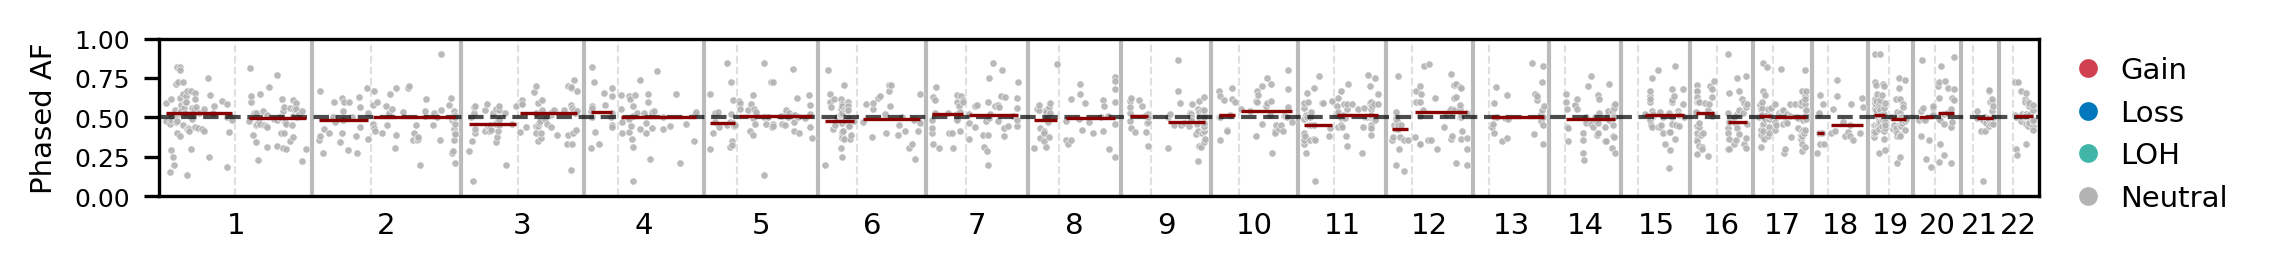

In [27]:
df = df_baf.loc[df_baf['group'] == 'seed_N'].copy()
print(df.shape)
df['gene_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, gw_prefix + "baf-seed_N.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1259, 10)


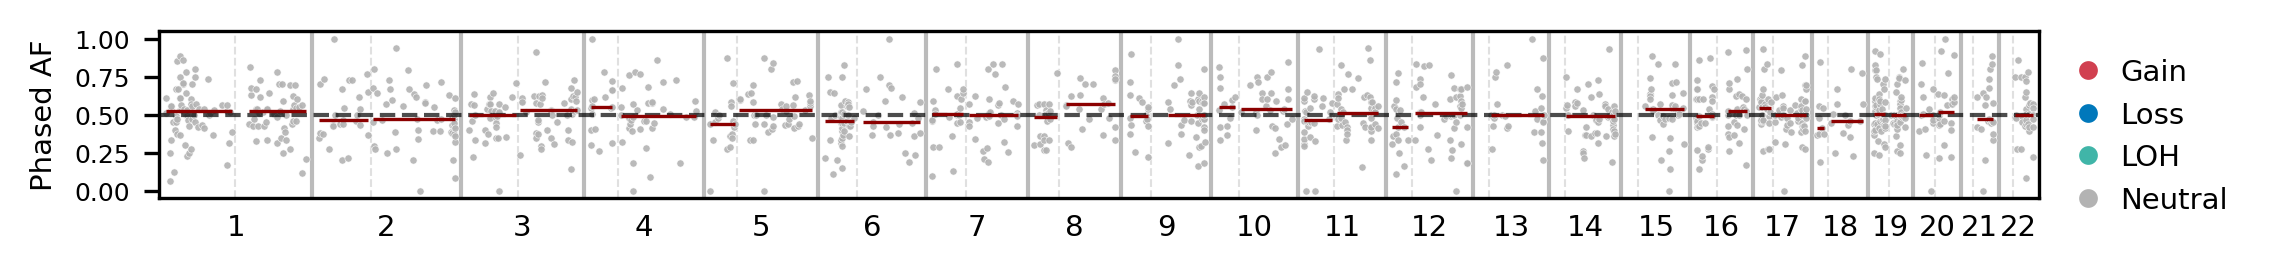

In [28]:
df = df_baf.loc[df_baf['group'] == 'stCNASim-rs_N'].copy()
print(df.shape)
df['gene_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, gw_prefix + "baf-stCNASim-rs_N.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1259, 10)


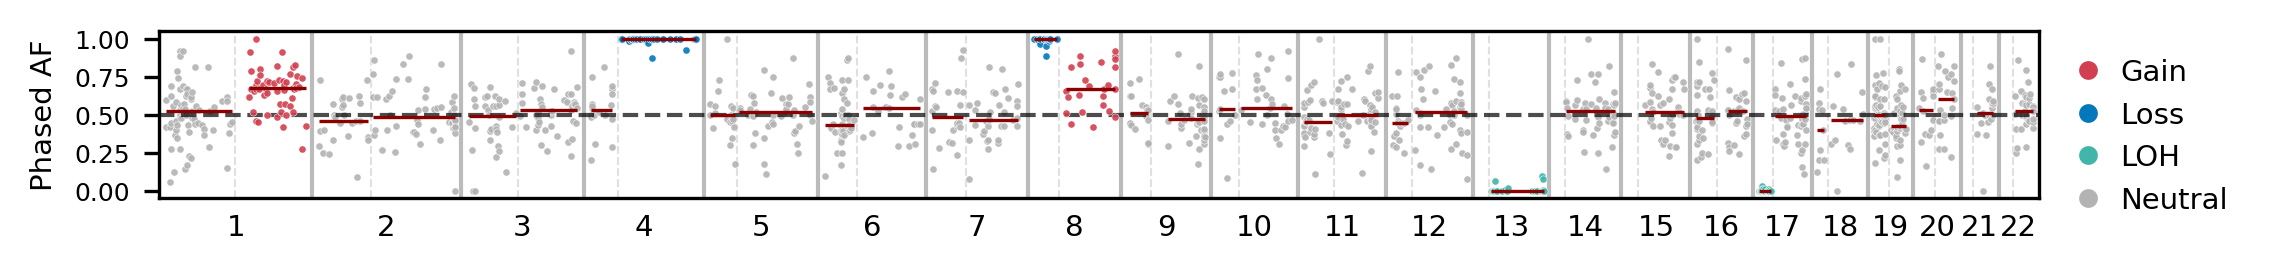

In [29]:
df = df_baf.loc[df_baf['group'] == 'stCNASim-rs_T'].copy()
print(df.shape)
fn = os.path.join(out_dir, gw_prefix + "baf-stCNASim-rs_T.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1250, 10)


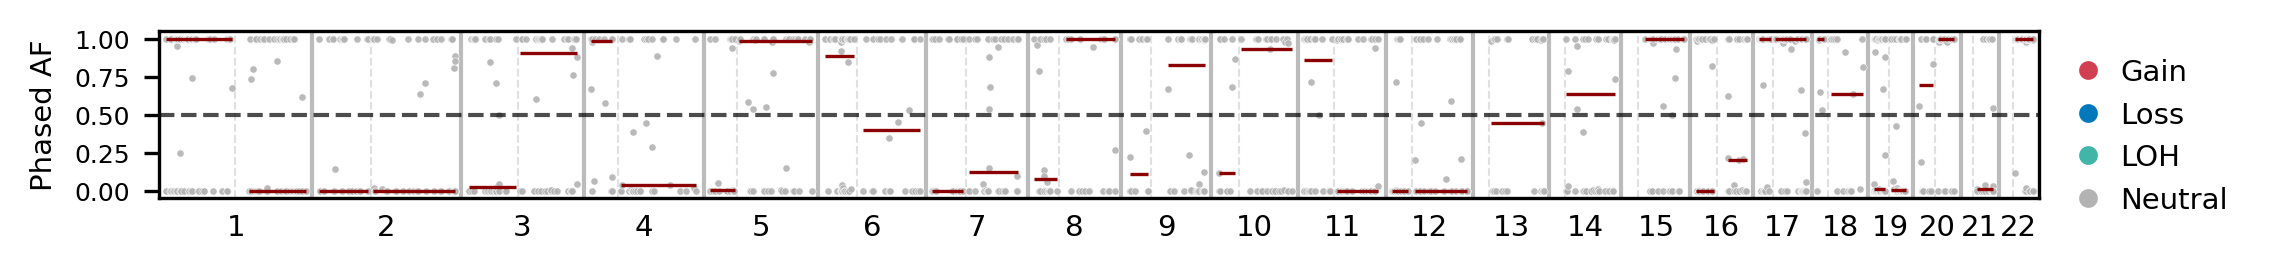

In [30]:
df = df_baf.loc[df_baf['group'] == 'scReadSim-cna_N'].copy()
print(df.shape)
df['gene_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, gw_prefix + "baf-scReadSim-cna_N.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1249, 10)


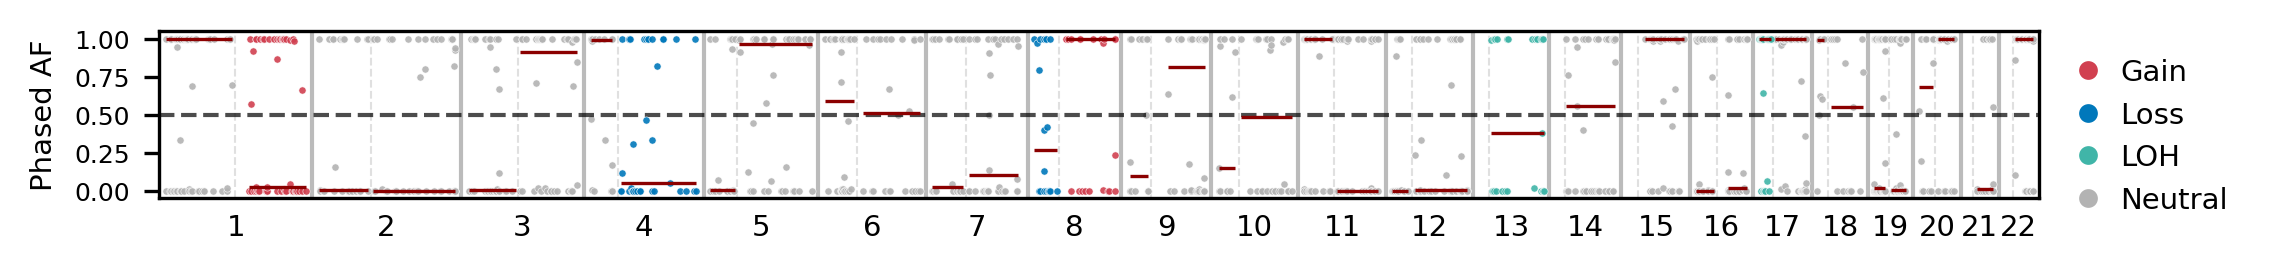

In [31]:
df = df_baf.loc[df_baf['group'] == 'scReadSim-cna_T'].copy()
print(df.shape)
fn = os.path.join(out_dir, gw_prefix + "baf-scReadSim-cna_T.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))